# <span style="color:#0F4C81;">第13章《红楼梦》文本数据分析</span>

本章将结合前面的知识进行文本数据分析,以中国古典四大名著之一的《红楼梦》为蓝本。《红楼梦》全书共120回，一直吸引着很多学者去研究。  

本章按照以下几个步骤进行文本数据分析和数据可视化。

(1)数据的准备、预处理、分词等；  
(2)各回的字数、词数、段落等相关方面的关系；  
(3)整体词频和词云的展示；  
(4)各回的聚类分析并可视化，主要进行了根据 **TF-IDF**（Term Frequency-Inverse Document Frequency, 词频逆文档频率）的系统聚类和根据词频的 LDA 主题模型聚类；
(5)人物关系网络的探索,主要绘制了各回的关系图和人物关系网络图。

## <span style="color:#006D5B;">准备工作</span>

1. 《红楼梦》的 TXT 版本；  
2. 《红楼梦》词典，用于辅助分词；  
3. 《红楼梦》人物词典；  
4. 《红楼梦》人物关系权重文件。 

In [7]:
# pip install jieba

## <span style="color:#006D5B;">分词</span>

分词常用于文本挖掘中。因为中文不像英文词汇之间有空格，所以中文分词和英文分词有很大的不同，中文分词通常使用训练好的分词模型。如中文分词常用的分词包有 jieba，本文就使用 Python 中的 jieba 分词库来进行分词。

### <span style="color:#6A1B9A;">读取数据</span>

In [8]:
## 读取停用词和需要的词典
import pandas as pd
import numpy as np
from pandas import read_csv
stopword = read_csv(r".\停用词.txt",header=None,names = ["Stopwords"])
mydict = read_csv(r".\专有词汇词典.txt",header=None, names=["Dictionary"])
print(stopword)
print("------------------------------")
print(mydict)

RedDream = read_csv(r".\红楼梦文本(UTF-8).txt",header=None,names = ["Reddream"])
RedDream

     Stopwords
0           ：“
1           。”
2           ？”
3            $
4            0
...        ...
2085        沙沙
2086         甭
2087         会
2088         砰
2089        说道

[2090 rows x 1 columns]
------------------------------
          Dictionary
0              皑皑轻趁步
1             爱彼之貌容兮
2               爱才好客
3                 艾官
4               暗渡陈仓
...              ...
4385  座上珠玑昭日月堂前黼黻焕烟霞
4386           昨夜朱楼梦
4387            昨尤我画
4388          且听下回分解
4389            下回分解

[4390 rows x 1 columns]


,Reddream
0,第1卷
1,第一回 甄士隐梦幻识通灵 贾雨村风尘怀闺秀
2,此开卷第一回也。作者自云：因曾历过一番梦幻之后，故将真事隐去，而借“通灵”之说，撰此<<...
3,此回中凡用“梦”用“幻”等字，是提醒阅者眼目，亦是此书立意本旨。
4,列位看官：你道此书从何而来？说起根由虽近荒唐，细按则深有趣味。待在下将此来历注明，方使阅...
...,...
3049,这一日空空道人又从青埂峰前经过，见那补天未用之石仍在那里，上面字迹依然如旧，又从头的细细...
3050,那空空道人牢牢记着此言，又不知过了几世几劫，果然有个悼红轩，见那曹雪芹先生正在那里翻阅历...
3051,那空空道人听了，仰天大笑，掷下抄本，飘然而去。一面走着，口中说道：“果然是敷衍荒唐！不但...
3052,说到辛酸处，荒唐愈可悲。


### <span style="color:#6A1B9A;"> 数据预处理 </span>

空值数量: Reddream    0
dtype: int64


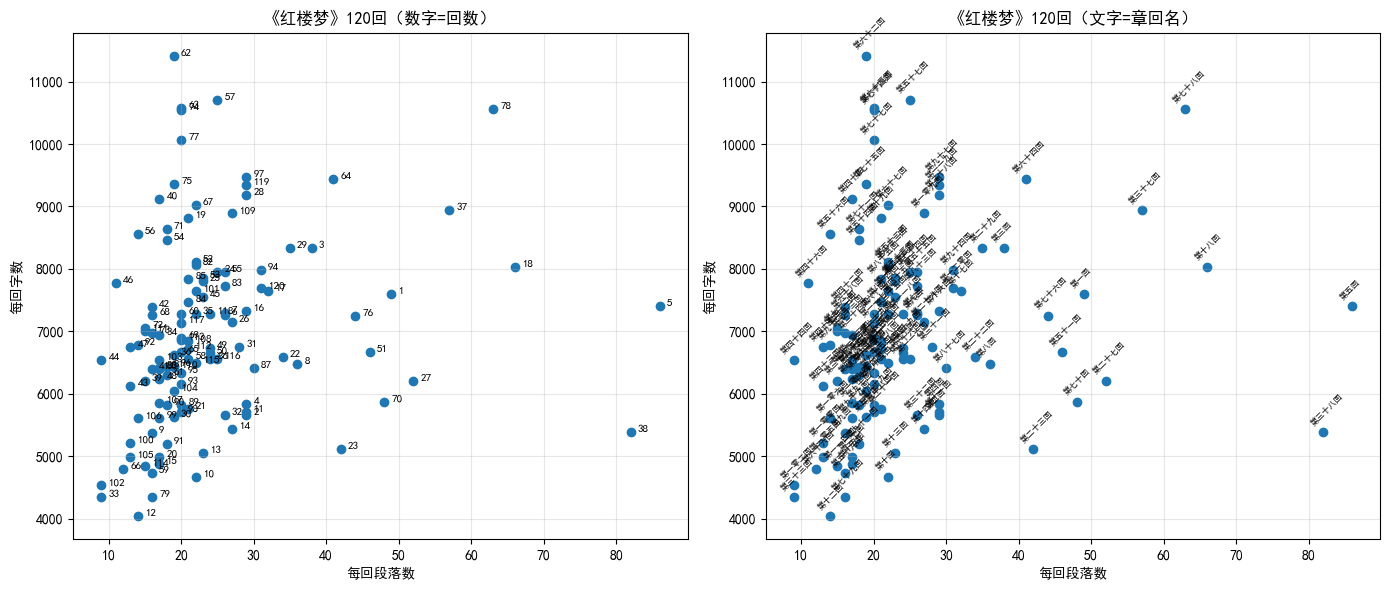


统计信息：
总回数: 120
平均每回字数: 6967
平均每回段落数: 24.4
最长回: 第第六十二回 (11414字)
最短回: 第第十二回 (4037字)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据清洗
print(f"空值数量: {np.sum(pd.isnull(RedDream), axis=0)}")

# 删除包含"卷"的行和空行
indexjuan = RedDream.Reddream.str.contains("^第+.+卷", na=False)
RedDream = RedDream[~indexjuan].dropna().reset_index(drop=True)

# 2. 找出章节标题
indexhui = RedDream.Reddream.str.match("^第+.+回", na=False)
chapnames = RedDream.Reddream[indexhui].reset_index(drop=True)

# 处理章节名
chapnamesplit = chapnames.str.split(" ", expand=True)
chapnamesplit.columns = ["Chapter", "Leftname", "Rightname"]

# 3. 构建数据框
Red_df = pd.DataFrame({
    "Chapter": chapnamesplit["Chapter"],
    "Leftname": chapnamesplit["Leftname"],
    "Rightname": chapnamesplit["Rightname"],
    "Chapter2": np.arange(1, len(chapnamesplit) + 1)
})

Red_df["ChapName"] = Red_df["Leftname"] + "," + Red_df["Rightname"]
Red_df["StartCid"] = indexhui[indexhui == True].index

# 4. 计算结束索引（使用 .loc 避免链式赋值）
Red_df["endCid"] = Red_df["StartCid"].shift(-1, fill_value=len(RedDream)-1) - 1
# 或者使用原来的方法但避免链式赋值：
# Red_df["endCid"] = Red_df["StartCid"][1:].reset_index(drop=True) - 1
# Red_df.loc[Red_df.index[-1], "endCid"] = RedDream.index[-1]

# 5. 计算段落长度
Red_df["Lengthchaps"] = Red_df["endCid"] - Red_df["StartCid"]

# 6. 提取章节内容（优化循环）
Red_df["Artical"] = ""
for ii in Red_df.index:
    start = Red_df.loc[ii, "StartCid"] + 1
    end = int(Red_df.loc[ii, "endCid"])
    chapid = np.arange(start, end)
    # 获取内容并替换空格
    content = "".join(RedDream.loc[chapid, "Reddream"].astype(str))
    Red_df.loc[ii, "Artical"] = content.replace("\u3000", "").replace(" ", "")

# 7. 计算字数
Red_df["lenzi"] = Red_df["Artical"].str.len()

# 8. 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 子图1：显示回数
ax1.scatter(Red_df["Lengthchaps"], Red_df["lenzi"])
for ii in Red_df.index:
    ax1.text(Red_df.loc[ii, "Lengthchaps"] + 1, 
             Red_df.loc[ii, "lenzi"], 
             Red_df.loc[ii, "Chapter2"], 
             fontsize=8)
ax1.set_xlabel("每回段落数")
ax1.set_ylabel("每回字数")
ax1.set_title("《红楼梦》120回（数字=回数）")
ax1.grid(True, alpha=0.3)

# 子图2：显示章节名
ax2.scatter(Red_df["Lengthchaps"], Red_df["lenzi"])
for ii in Red_df.index:
    ax2.text(Red_df.loc[ii, "Lengthchaps"] - 2, 
             Red_df.loc[ii, "lenzi"] + 100, 
             Red_df.loc[ii, "Chapter"], 
             fontsize=6, 
             rotation=45)
ax2.set_xlabel("每回段落数")
ax2.set_ylabel("每回字数")
ax2.set_title("《红楼梦》120回（文字=章回名）")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 9. 输出统计信息
print(f"\n统计信息：")
print(f"总回数: {len(Red_df)}")
print(f"平均每回字数: {Red_df['lenzi'].mean():.0f}")
print(f"平均每回段落数: {Red_df['Lengthchaps'].mean():.1f}")
print(f"最长回: 第{Red_df.loc[Red_df['lenzi'].idxmax(), 'Chapter']} ({Red_df['lenzi'].max()}字)")
print(f"最短回: 第{Red_df.loc[Red_df['lenzi'].idxmin(), 'Chapter']} ({Red_df['lenzi'].min()}字)")

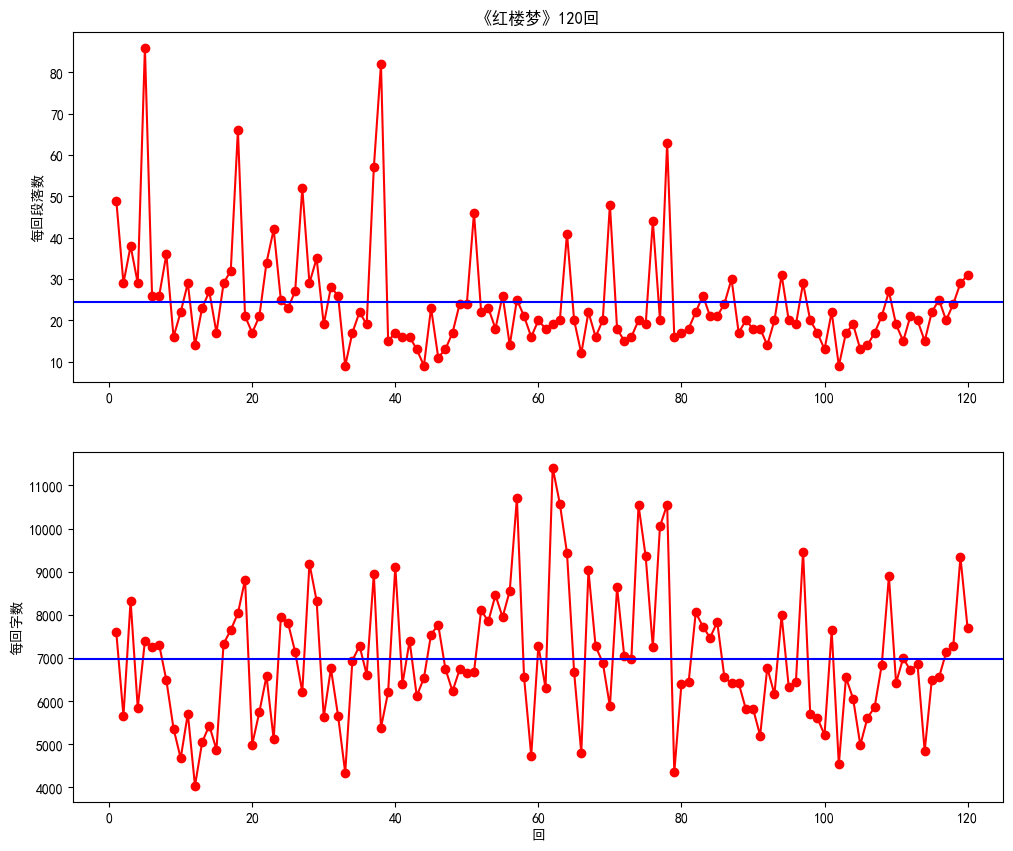

In [10]:
plt.figure(figsize=(12,10))
plt.subplot(2,1,1)
plt.plot(Red_df.Chapter2,Red_df.Lengthchaps,"ro-",label="段落")
plt.ylabel("每回段落数")
plt.title("《红楼梦》120回")

## 添加平均值线
plt.hlines(np.mean(Red_df.Lengthchaps),-5,125,"b")
plt.xlim((-5,125))
plt.subplot(2,1,2)
plt.plot(Red_df.Chapter2,Red_df.lenzi,"ro-",label = "段落")
plt.xlabel("回")
plt.ylabel("每回字数")

## 添加平均值线
plt.hlines(np.mean(Red_df.lenzi),-5,125,"b")
plt.xlim((-5,125))
plt.show()    

### <span style="color:#6A1B9A;"> 对《红楼梦》进行分词 </span>

此处我们继续使用jieba来分词

In [11]:
import jieba
import pandas as pd

Red_df = Red_df.copy()

def cut_text(text):
    words = pd.Series(jieba.cut(text, cut_all=True))
    words = words[words.str.len() > 1]
    words = words[~words.isin(stopword)]
    return words.values

Red_df["cutword"] = Red_df["Artical"].apply(cut_text)

## 查看全文的分词结果
Red_df["cutword"]

f:\My-study\.venv\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\huawei\AppData\Local\Temp\jieba.cache
Loading model cost 0.828 seconds.
Prefix dict has been built successfully.


0      [开卷, 第一, 第一回, 一回, 作者, 一番, 梦幻, 之后, 真事, 隐去, 之说, ...
1      [诗云, 一局, 输赢, 逡巡, 目下, 兴衰, 旁观, 冷眼, 却说, 封肃, 听见, 公...
2      [却说, 回头, 不是, 别人, 乃是, 当日, 同僚, 一案, 张如圭, 本系, 此地, ...
3      [却说, 姊妹, 王夫人, 夫人, 王夫人, 夫人, 兄嫂, 计议, 家务, 姨母, 遭人,...
4      [第四, 第四回, 四回, 回中, 家母, 母子, 荣府内, 寄居, 事略, 表明, 暂不,...
                             ...                        
115    [宝玉, 的话, 往后, 往后仰, 后仰, 死去, 王夫人, 夫人, 哭叫, 不止, 自知,...
116    [王夫人, 夫人, 打发, 发人, 过去, 商量, 宝玉, 听见, 和尚, 在外, 外头, ...
117    [说话, 邢王二, 王二夫人, 夫人, 一段, 一段话, 明知, 挽回, 王夫人, 夫人, ...
118    [宝玉, 说话, 摸不着, 摸不着头脑, 不着, 头脑, 听宝玉, 宝玉, 说道, ：“, ...
119    [不好, 连忙, 进去, 巧姐儿, 姐儿, 平儿, 随着, 走到, 只见, 人心, 心痛, ...
Name: cutword, Length: 120, dtype: object

### <span style="color:#6A1B9A;"> 绘制词云图 </span>
使用 Python 中的 WorldCloud 库进行词云绘制

#### <span style="color:#BF6D00;">绘制《红楼梦》全文词云图</span>

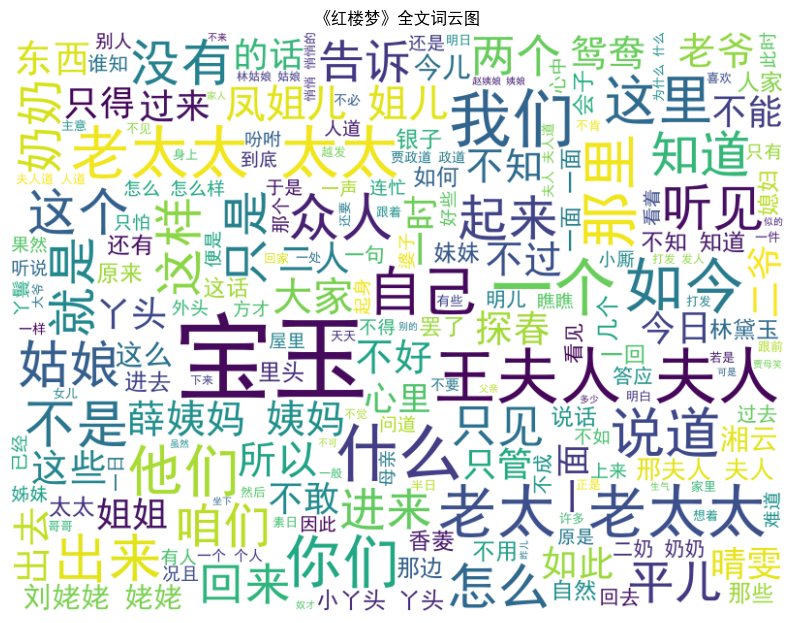

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 合并所有章节的分词
all_words = []
for words in Red_df['cutword']:
    all_words.extend(words)

# 将词语列表转换为字符串
text = " ".join(all_words)

# 生成词云
wordcloud = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",  # 指定中文字体
    width=800,
    height=600,
    background_color="white",
    max_words=200,
    max_font_size=100
).generate(text)

# 显示词云图
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("《红楼梦》全文词云图")
plt.show()


#### <span style="color:#BF6D00;">绘制《红楼梦》全文词云图（带背景图片）</span>

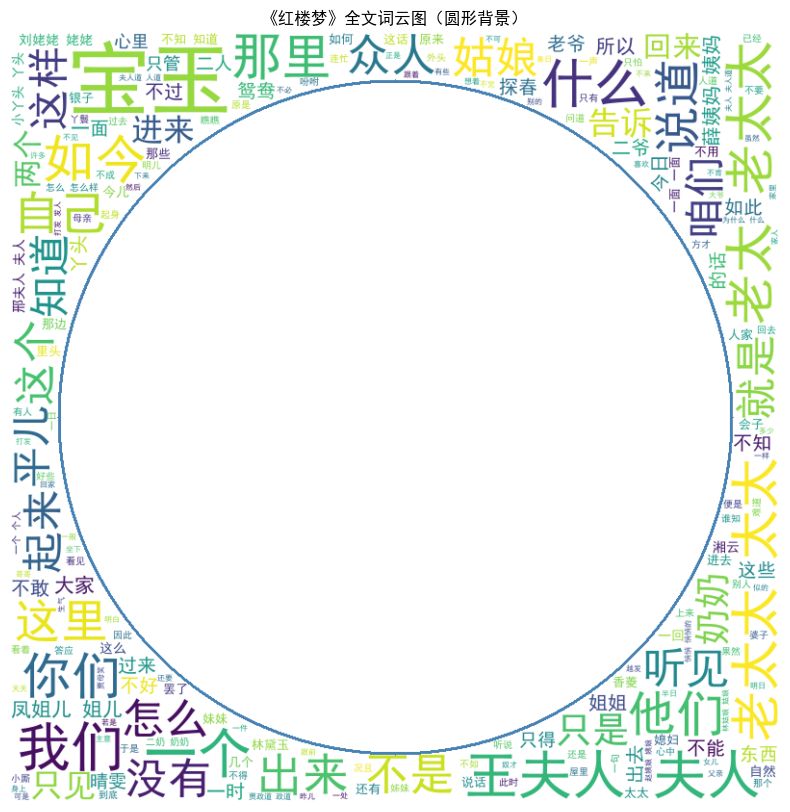

In [13]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 合并所有章节的分词
all_words = []
for words in Red_df['cutword']:
    all_words.extend(words)

text = " ".join(all_words)

# 创建一个简单的圆形背景图片
def create_circular_mask():
    x, y = np.ogrid[:800, :800]
    center = (400, 400)
    radius = 350
    mask = (x - center[0])**2 + (y - center[1])**2 <= radius**2
    mask = np.uint8(mask * 255)
    return mask

# 创建掩码
mask = create_circular_mask()

# 生成带背景的词云
wordcloud = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",
    mask=mask,
    background_color="white",
    contour_width=3,
    contour_color='steelblue',
    max_words=200
).generate(text)

# 显示词云图
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("《红楼梦》全文词云图（圆形背景）")
plt.show()


#### <span style="color:#BF6D00;">绘制词语频数的直方图</span>

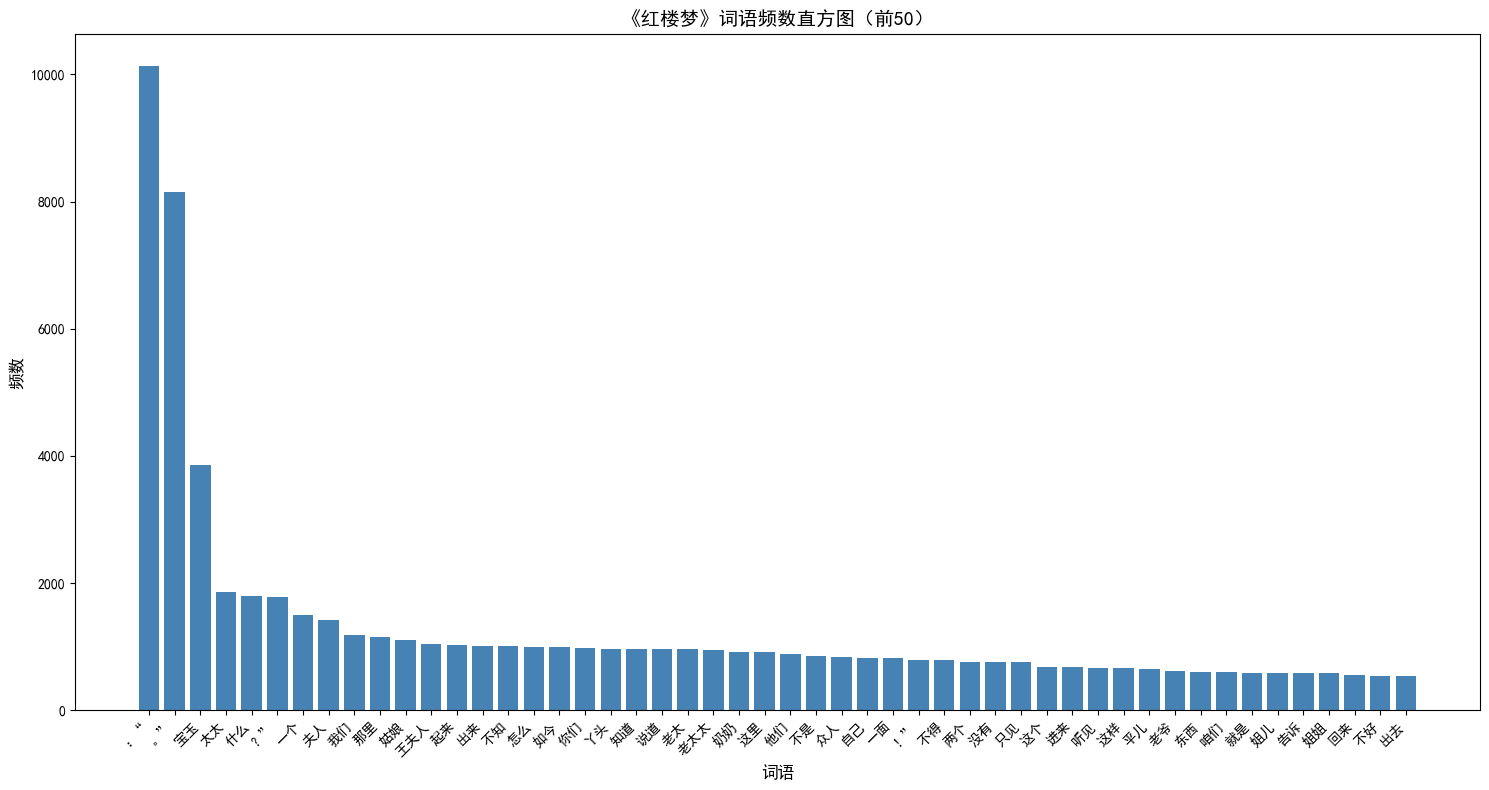

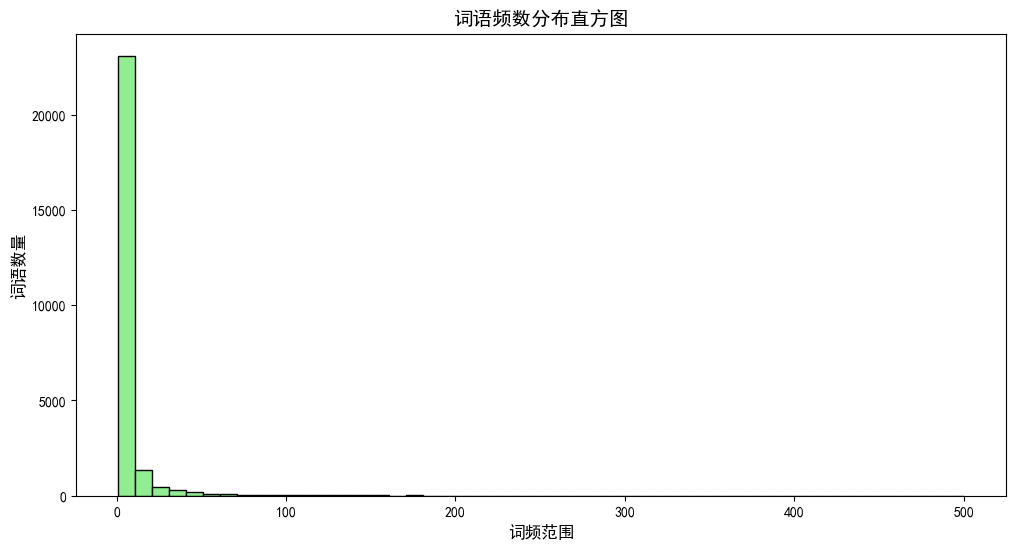

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

# 合并所有章节的分词
all_words = []
for words in Red_df['cutword']:
    all_words.extend(words)

# 统计词频
word_counts = Counter(all_words)

# 取出现频率最高的前50个词
top_words = word_counts.most_common(50)
words, counts = zip(*top_words)

# 绘制词语频数直方图
plt.figure(figsize=(15, 8))
plt.bar(words, counts, color='steelblue')
plt.xlabel('词语', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.title('《红楼梦》词语频数直方图（前50）', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()  # 自动调整布局
plt.show()

# 也可以绘制词频分布的直方图（观察词频的分布情况）
plt.figure(figsize=(12, 6))
plt.hist(list(word_counts.values()), bins=50, range=(1, 500), color='lightgreen', edgecolor='black')
plt.xlabel('词频范围', fontsize=12)
plt.ylabel('词语数量', fontsize=12)
plt.title('词语频数分布直方图', fontsize=14)
plt.show()


## <span style="color:#006D5B;">文本聚类分析（了解）</span>

机器学习和自然语言处理（NLP）中非常经典的文本挖掘与数据可视化工具。我们可以把它们串联成一个完整的流程：先将文字转化为数字（TF-IDF），然后对数据进行降维和可视化（PCA, MDS, t-SNE），最后把相似的文本归为一类（K均值, 层次聚类）。

### <span style="color:#6A1B9A;"> 构建分词 TF-IDF 矩阵 </span>

计算机是看不懂汉字的，它只能算数字。所以我们需要把文本变成一个数学矩阵。

- 分词：把一句话切分成一个个词。比如“我爱吃苹果”变成 ['我', '爱', '吃', '苹果']。

- TF-IDF：一种用来评估一个词对于一篇文章有多重要的算法。

    - TF (词频)：这个词在文章中出现的次数越多越重要。

    - IDF (逆文档频率)：如果一个词在所有文章里都出现（比如“的”、“了”、“我们”），那它就失去了区分度，重要性就会被降低；反之，如果某个专业词汇只在几篇文章里出现，它就很关键。

- TF-IDF 矩阵：把所有文章和所有词汇画成一个表格（矩阵），行是文章，列是词汇，格子里的数字就是该词在这篇文章中的 TF-IDF 权重值。

### <span style="color:#6A1B9A;"> 使用 TF-IDF矩阵对各回进行聚类 </span>

使用 TF-IDF 矩阵对各回进行聚类 的意思就是：利用上面算好的数字表格，自动把内容相似的“回”（比如《红楼梦》或《三国演义》的每一回）划分到同一个组里。

#### <span style="color:#BF6D00;">K均值聚类</span>

怎么做：你先指定要分多少个堆（假设 $K=3$）。算法会在数据中随机选 3 个点作为“中心”，然后让每篇文章寻找离自己最近的中心靠拢。接着，中心点会根据组内成员的位置不断调整，直到大家的位置都稳定下来。

特点：速度极快，适合大数据量。缺点是你必须提前告诉它要分几类。

#### <span style="color:#BF6D00;">HC层次聚类</span>

怎么做：它就像在画“家族树”。一开始，每篇文章都自成一类。然后算法会找出最相似的两篇文章，把它们合并成一类；接着再找出次相似的合并……以此类推，直到所有文章都合并成一个大类。  

特点：最终会生成一个像树状图（Dendrogram）一样的结构。你不需要提前指定分几类，可以通过看“树枝”的疏密来决定在哪个高度切一刀来分类。

#### <span style="color:#BF6D00;">为什么要降维？ </span>

在 TF-IDF 矩阵中，如果有 10,000 个不同的词，那每篇文章就有 10,000 个维度。人类的眼睛只能看懂 2 维（平面）或 3 维（空间）的图，根本无法想象 10,000 维长什么样。所以我们需要降维算法，把一万维的特征浓缩到 2 维或 3 维，这样就能在屏幕上画出散点图了。

#### <span style="color:#BF6D00;">MDS降维</span>

原理解析：它的核心目标是保持物体之间的“距离”不变。假设在 10,000 维的空间里，第一回和第二回距离很近，第一回和第一百回距离很远。MDS 降维到 2 维后，会尽量让它们在平面上的距离依然保持这种远近关系。

特点：非常直观，专门为了维持样本间的相似度/差异度而设计。

#### <span style="color:#BF6D00;">PCA降维</span>

原理解析：这是一种线性降维方法。它就像是用手电筒照一个 3D 的物体，在墙上投下一个 2D 的影子。PCA 的目标是调整手电筒的角度，使得投影出来的影子“看起来最清楚”、保留的信息（方差）最多。

特点：计算速度非常快，擅长捕捉全局的几何结构，但不擅长处理复杂的扭曲数据。

#### <span style="color:#BF6D00;">t-SNE高维数据可视化</span>

原理解析：这是一种极度强大的非线性降维算法。它非常注重“邻居关系”。在高维空间里是一伙的（聚类），降维到二维平面后，t-SNE 会用一种像“弹簧”一样的数学力，把它们牢牢聚在一起，而把不是一伙的推得远远的。

特点：是目前高维数据可视化最常用的神器。画出来的图聚类边界非常清晰，漂亮而且好认。唯一的缺点是计算比较慢。

## <span style="color:#006D5B;"> LDA 主题模型（了解）</span>

LDA（Latent Dirichlet Allocation，隐含狄利克雷分配）是一种自动发现文本主题的方法。  

可以把它理解成：
> 给机器一大堆文章，但不告诉它主题是什么，让机器自己总结出这些文章主要在谈什么。

假设你有 100 篇新闻.

文章1：梅西 世界杯 阿根廷 足球 冠军  
文章2：C罗 足球 欧冠 进球 皇马  
文章3：苹果 iPhone 芯片 手机 发布  
文章4：华为 手机 麒麟 芯片  
文章5：比特币 区块链 数字货币  
文章6：以太坊 区块链 智能合约  
  
......  
  
LDA分析后可能发现

主题1: 足球 世界杯 梅西 C罗 进球 冠军 （体育主题）  
主题2: 手机 芯片 苹果 华为 iPhone 麒麟 （科技主题）  
主题3：比特币 区块链 数字货币 以太坊 （加密货币主题）  


一篇文章 可能 多个主题混合

所以LDA不是说某一回属于某个主题，而是给出的是主题分布（Topic Distribution）

第1回  
爱情 ████████ 80%  
家族 ██ 20%  

第2回  
爱情 █████ 50%  
家族 ███ 30%  
诗词 ██ 20%  

第3回  
家族 ███████ 70%  
爱情 ██ 20%  
诗词 █ 10%  

## <span style="color:#006D5B;">人物社交网络分析（了解）</span>

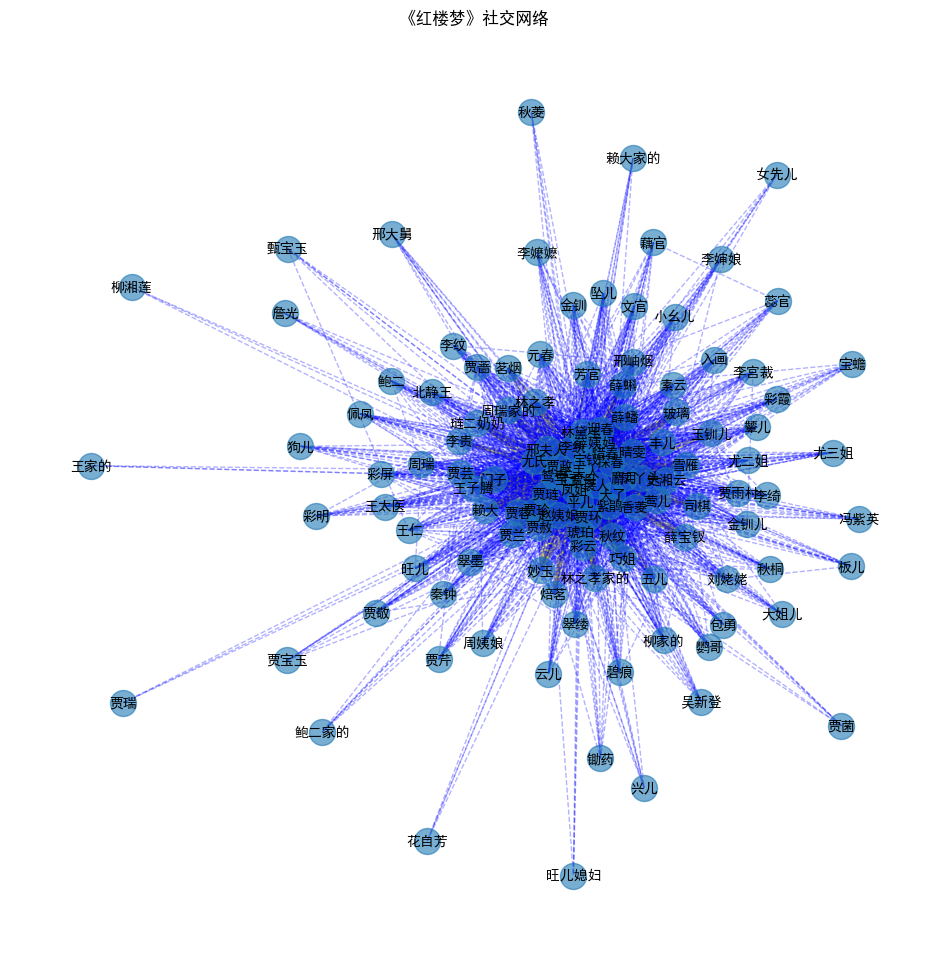

<Figure size 3000x1500 with 0 Axes>

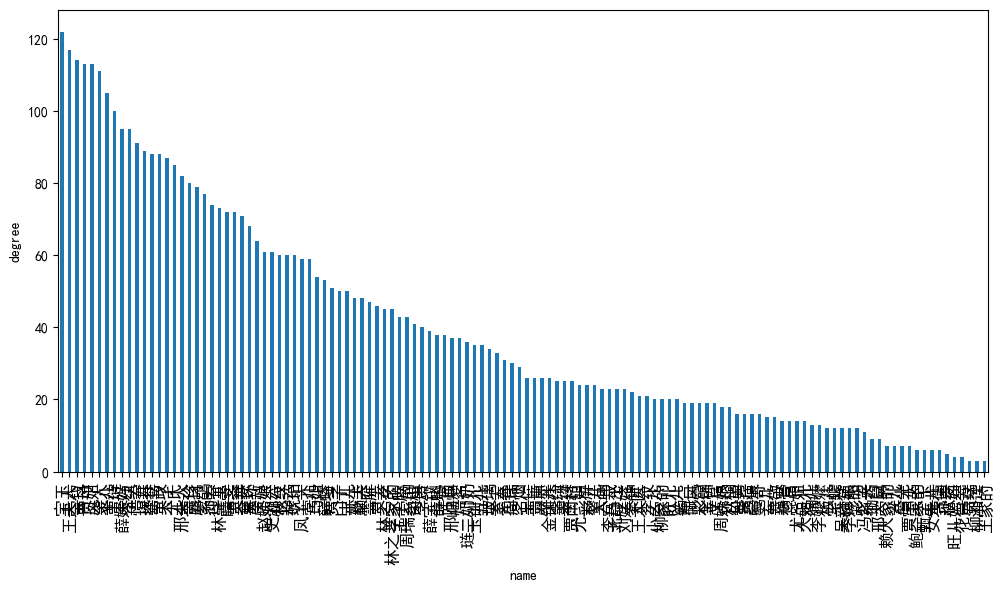

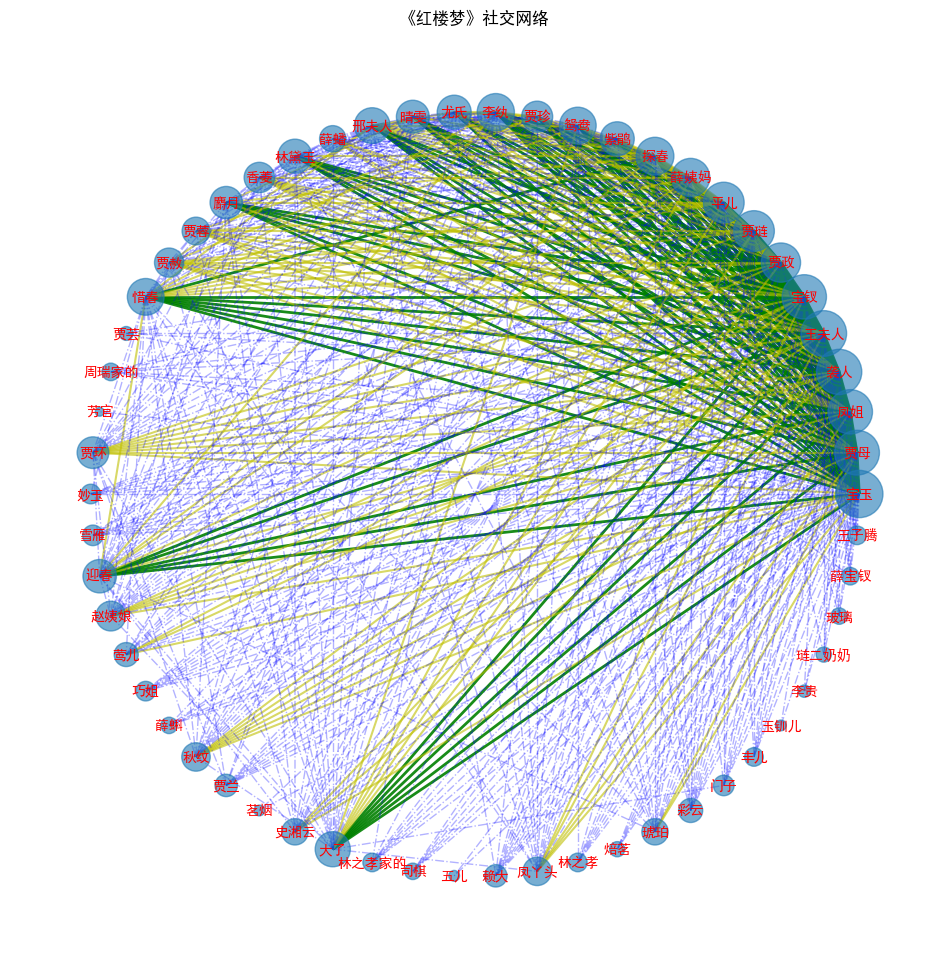

In [15]:
import networkx as nx
## 读取数据
Red_df = pd.read_csv(r".\红楼梦社交网络权重.csv")
Red_df.head()    

# 计算其中的一种权重
Red_df["weight"] = Red_df.chapweight / 120
Red_df2 = Red_df[Red_df.weight >0.025].reset_index(drop = True)
plt.figure(figsize=(12,12))
## 生成社交网络图
G=nx.Graph()
## 添加边
for ii in Red_df2.index:
    G.add_edge(Red_df2.First[ii],Red_df2.Second[ii],weight = Red_df2.weight[ii])
## 定义3种边
elarge=[(u,v) for (u,v,d) in G.edges(data=True) if d['weight'] >0.2]
emidle = [(u,v) for (u,v,d) in G.edges(data=True) if (d['weight'] >0.1) & (d['weight'] <= 0.2)]
esmall=[(u,v) for (u,v,d) in G.edges(data=True) if d['weight'] <=0.1]
## 图的布局
pos=nx.spring_layout(G) # positions for all nodes
# nodes
nx.draw_networkx_nodes(G,pos,alpha=0.6,node_size=350)
# edges
nx.draw_networkx_edges(G,pos,edgelist=elarge,width=2,alpha=0.9,edge_color='g')
nx.draw_networkx_edges(G,pos,edgelist=emidle,width=1.5,alpha=0.6,edge_color='y')
nx.draw_networkx_edges(G,pos,edgelist=esmall,width=1,alpha=0.3,edge_color='b',style='dashed')
# labels
nx.draw_networkx_labels(G,pos,font_size=10)
plt.axis('off')
plt.title("《红楼梦》社交网络")
plt.show()  



## 计算每个节点的度
plt.figure(figsize=(30,15))
Gdegree = nx.degree(G)
Gdegree = dict(Gdegree)
Gdegree = pd.DataFrame({"name":list(Gdegree.keys()),"degree":list(Gdegree.values())})
Gdegree.sort_values(by="degree",ascending=False).plot(
               x = "name",
               y = "degree",
               kind="bar",
               figsize=(12,6),
               legend=False)
plt.xticks(size = 12)
plt.ylabel("degree")
plt.savefig('gx.png')
plt.show()


    
    
plt.figure(figsize=(12,12))
## 生成社交网络图
Red_df2 = Red_df[Red_df.weight >0.1].reset_index(drop = True)#为了控制图中圆圈上的点数（人）将权重从0.025提高到0.1
G=nx.Graph()

## 添加边
for ii in Red_df2.index:
    G.add_edge(Red_df2.First[ii],Red_df2.Second[ii],weight = Red_df2.weight[ii])
## 定义两种边
elarge=[(u,v) for (u,v,d) in G.edges(data=True) if d['weight'] >0.3]
emidle = [(u,v) for (u,v,d) in G.edges(data=True) if (d['weight'] >0.2) & (d['weight'] <= 0.3)]
esmall=[(u,v) for (u,v,d) in G.edges(data=True) if d['weight'] <=0.2]

## 图的布局
pos=nx.circular_layout(G) # positions for all nodes
#pos=nx.random_layout(G)

##计算节点的度
Gdegree = nx.degree(G)
Gdegree = dict(Gdegree)
Gdegree = pd.DataFrame({"name":list(Gdegree.keys()),"degree":list(Gdegree.values())})

# nodes根据节点的入度和初度来设置节点的大小
nx.draw_networkx_nodes(G,pos,alpha=0.6,node_size=20 + Gdegree.degree * 20)
#nx.draw_networkx(G,pos,node_color='y',node_size=500,font_size=10,font_color='r')

# edges
nx.draw_networkx_edges(G,pos,edgelist=elarge, width=2,alpha=0.9,edge_color='g') #alpha是透明度，width是连接线的宽度
nx.draw_networkx_edges(G,pos,edgelist=emidle,width=1.5,alpha=0.6,edge_color='y')
nx.draw_networkx_edges(G,pos,edgelist=esmall,width=1,alpha=0.3,edge_color='b',style='dashdot')

# labels
nx.draw_networkx_labels(G,pos,font_size=10,font_color='r')# font_size=10设置图中字体的大小
plt.axis('off')
plt.title("《红楼梦》社交网络")
plt.savefig(r'图13-34 circular_layout(G)节点图.png')#将图像保存
plt.show() # display


## <span style="color:#006D5B;">本章小结</span>

通过对《红楼梦》文本数据的分析，向大家展示了文本数据的处理方法、文本聚类分析的方法，以及 LDA 主题模型和社交网络分析方法。